Import Libraries

In [48]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

In [4]:
train_data = '/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/train'
paths = []
labels = []

folders_paths = os.listdir(train_data)

for path in folders_paths:
    folder_path = os.path.join(train_data, path)     
    folder_name = os.listdir(folder_path)
    
    for image in folder_name:
        image_name = os.path.join(folder_path, image)  
        paths.append(image_name)
        labels.append(path)

Aseries = pd.Series(paths, name='Paths')
Bseries = pd.Series(labels, name='Labels')
train = pd.concat([Aseries, Bseries],axis=1)
train

,Paths,Labels
0,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
1,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
2,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
3,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
4,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
...,...,...
246,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
247,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
248,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
249,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid


Dataset Setup

In [5]:
test_data = '/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test'
paths = []
labels = []

folders_paths = os.listdir(test_data)

for path in folders_paths:
    folder_path = os.path.join(test_data, path)     
    folder_name = os.listdir(folder_path)
    
    for image in folder_name:
        image_name = os.path.join(folder_path, image)  
        paths.append(image_name)
        labels.append(path)

Aseries = pd.Series(paths, name='Paths')
Bseries = pd.Series(labels, name='Labels')
test = pd.concat([Aseries, Bseries],axis=1)
test

,Paths,Labels
0,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
1,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
2,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
3,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
4,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
...,...,...
61,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
62,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
63,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
64,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid


In [6]:
train["Labels"].unique()

array(['Normal', 'Viral Pneumonia', 'Covid'], dtype=object)

In [7]:
classes = train["Labels"].value_counts()
classes

Labels
Covid              111
Normal              70
Viral Pneumonia     70
Name: count, dtype: int64

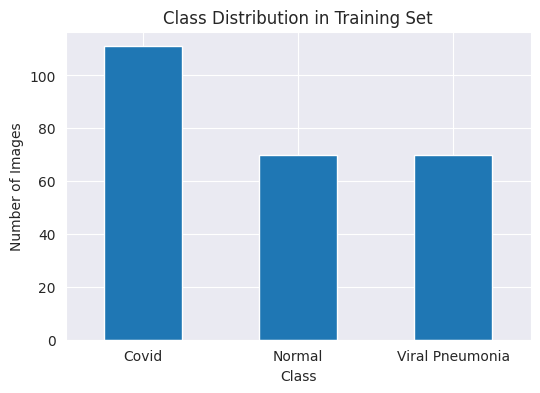

In [8]:
plt.figure(figsize=(6,4))
classes.plot(kind='bar')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

Preprocessing

In [9]:
test1,valid = train_test_split(test, train_size=0.5,shuffle= True , random_state=43)

In [10]:
test1

,Paths,Labels
28,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
42,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
56,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
9,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
10,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
32,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
24,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
12,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
36,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
4,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal


In [11]:
valid

,Paths,Labels
26,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
5,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
48,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
40,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
22,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
65,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid
33,/kaggle/input/datasets/pranavraikokte/covid19-...,Viral Pneumonia
19,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
14,/kaggle/input/datasets/pranavraikokte/covid19-...,Normal
59,/kaggle/input/datasets/pranavraikokte/covid19-...,Covid


In [34]:
img_size=(224,224)
batch_size= 16
tr_gen = ImageDataGenerator()
val_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()
train_gen = tr_gen.flow_from_dataframe(train,
                                      x_col='Paths',
                                      y_col='Labels',
                                      target_size=img_size,
                                      class_mode='categorical',
                                      color_mode='rgb',
                                      batch_size=batch_size,
                                      shuffle=True)
valid_gen = val_gen.flow_from_dataframe(valid,
                                      x_col='Paths',
                                      y_col='Labels',
                                      target_size=img_size,
                                      class_mode='categorical',
                                      color_mode='rgb',
                                      batch_size=batch_size,
                                      shuffle=True)
test_gen = ts_gen.flow_from_dataframe(test,
                                      x_col='Paths',
                                      y_col='Labels',
                                      target_size=img_size,
                                      class_mode='categorical',
                                      color_mode='rgb',
                                      batch_size=batch_size,
                                      shuffle=False)

Found 251 validated image filenames belonging to 3 classes.
Found 33 validated image filenames belonging to 3 classes.
Found 66 validated image filenames belonging to 3 classes.


A Sample from Train model


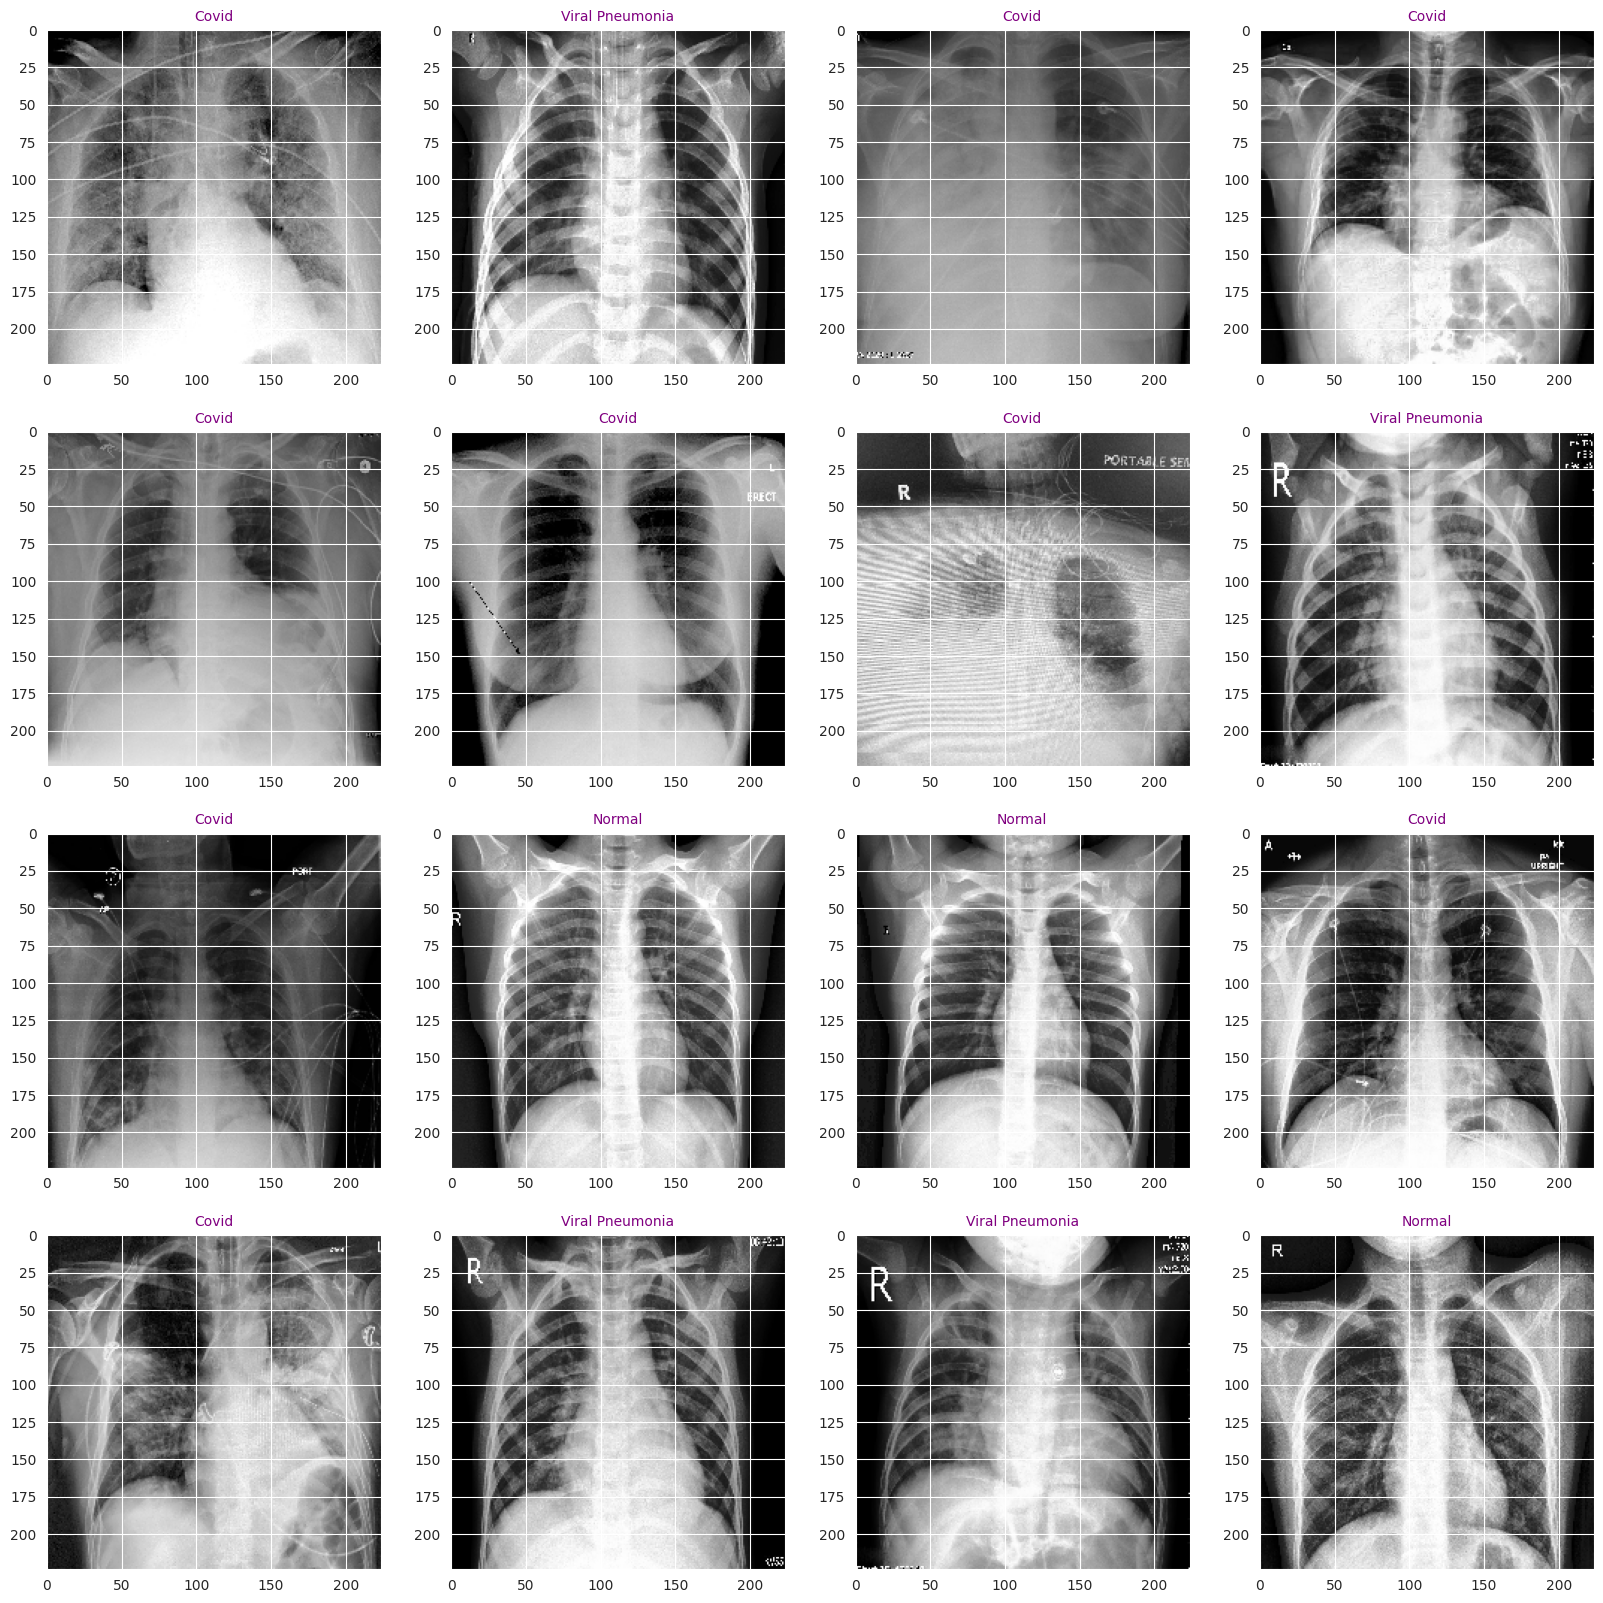

In [13]:
T_dect = train_gen.class_indices
classes = list(T_dect.keys())
images , labels = next(train_gen)

plt.figure(figsize=(20,20))
for i in range(16):
    plt.subplot(4,4,i+1)
    image = images[i]/255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color = 'purple', fontsize= 10)
    

Model training


* EfficientNet

In [20]:
img_shape = (img_size[0], img_size[1] , 3)
Num_class= len(classes)
base_model=tf.keras.applications.EfficientNetB7(include_top=False,weights=None,input_shape=img_shape,pooling='max')
base_model.load_weights('/kaggle/input/datasets/omarmahmouud/error-downloading/efficientnetb7_notop.h5')
model= Sequential([
    base_model,
    BatchNormalization(),
    Dense(256,activation='relu'),
    Dropout(0.2),
    Dense(Num_class,activation='softmax')
])
model.compile(optimizer=Adamax(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb7 (Functional)     │ (None, 2560)           │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2560)           │        10,240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,764,314 (247.06 MB)

 Trainable params: 64,448,467 (245.85 MB)

 Non-trainable params: 315,847 (1.20 MB)

In [22]:
history= model.fit(x=train_gen,epochs=15,verbose=1,validation_data=valid_gen,validation_steps=None,shuffle=False)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 479s 19s/step - accuracy: 0.6842 - loss: 0.7857 - val_accuracy: 0.3939 - val_loss: 2.9366
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 299s 19s/step - accuracy: 0.9548 - loss: 0.1174 - val_accuracy: 0.3030 - val_loss: 3.4744
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 289s 18s/step - accuracy: 0.9903 - loss: 0.0454 - val_accuracy: 0.3030 - val_loss: 4.0257
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 331s 19s/step - accuracy: 0.9962 - loss: 0.0129 - val_accuracy: 0.3636 - val_loss: 3.0960
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 291s 18s/step - accuracy: 0.9846 - loss: 0.0347 - val_accuracy: 0.4848 - val_loss: 1.8870
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 335s 21s/step - accuracy: 0.9844 - loss: 0.0356 - val_accuracy: 0.5455 - val_loss: 1.4255
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 306s 19s/step - accuracy: 0.9746 - loss: 0.0587 - val_accuracy: 0.7273 - val_loss: 0.6086
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 283s 18s/step - accuracy: 0.9892 - loss: 0.0229 - val_accuracy: 0.

Model evaluation  

In [23]:
train_acc=history.history['accuracy']
train_loss=history.history['loss']
val_acc=history.history['val_accuracy']
val_loss=history.history['val_loss']
index_loss=np.argmin(val_loss)
val_lowest=val_loss[index_loss]
index_acc=np.argmin(val_acc)
val_highest=val_acc[index_acc]
Epochs=[i+1 for i in range(len(train_acc))]
loss_label=f'best epochs={str(index_loss +1)}'
acc_label=f'best epochs={str(index_acc +1)}'

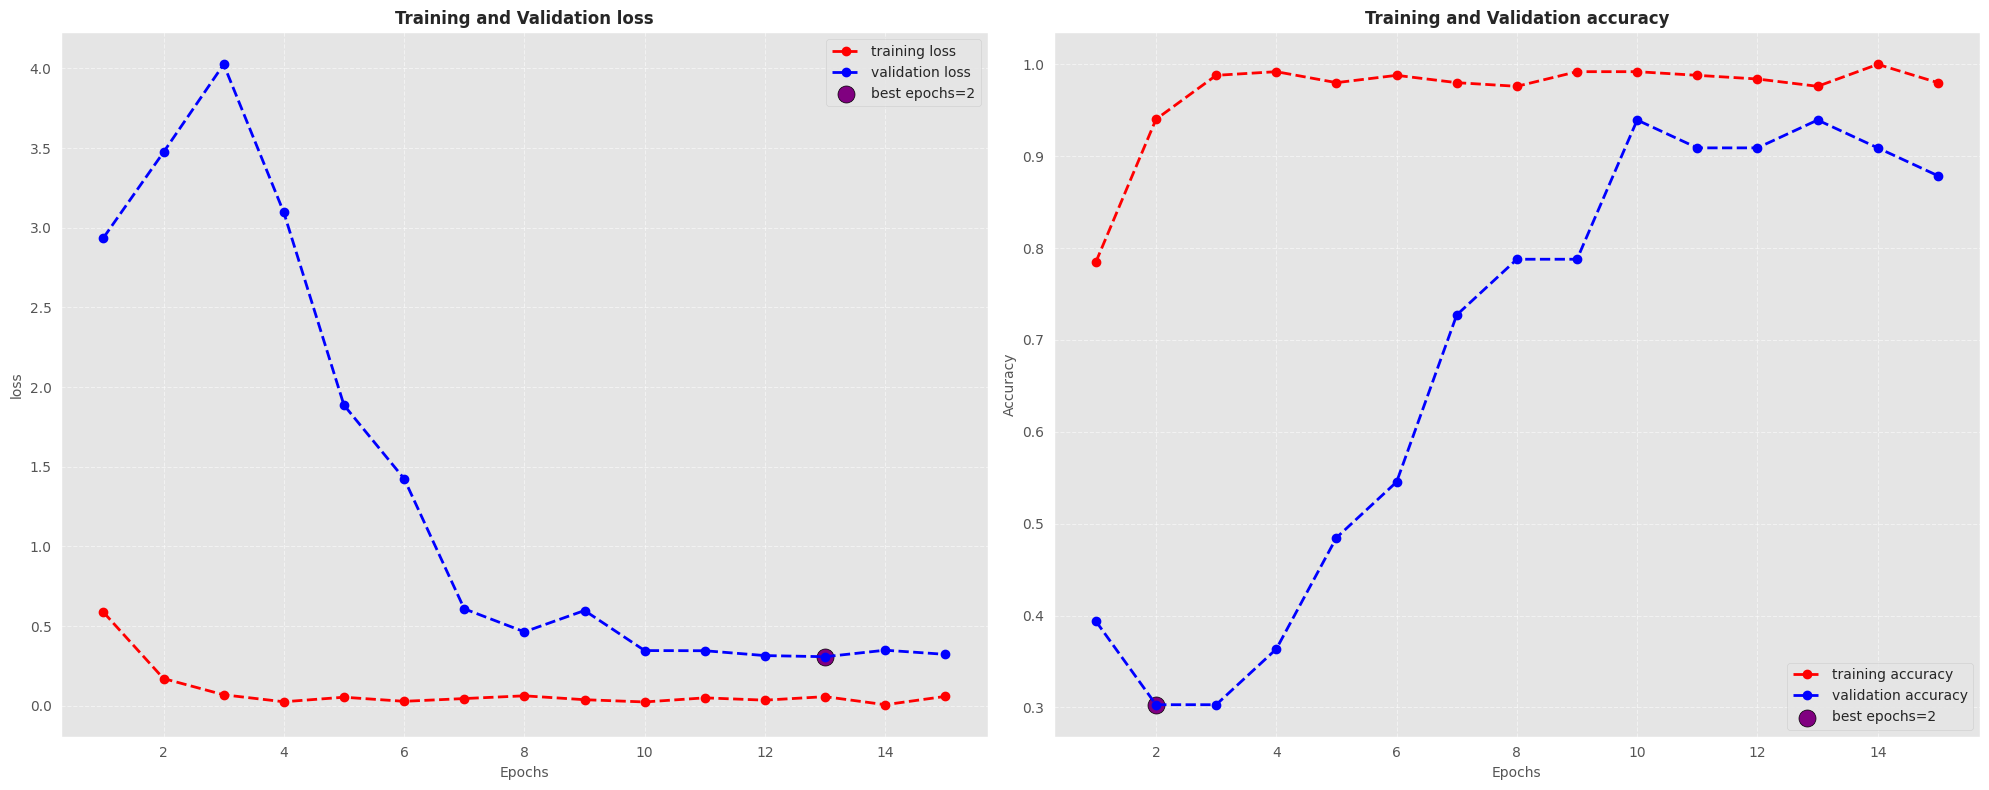

In [24]:
plt.figure(figsize=(20,8))
plt.style.use("ggplot")

#accuracy plot
plt.subplot(1,2,2)
plt.plot(Epochs,train_acc,'r--',linewidth=2,marker='o',label='training accuracy')
plt.plot(Epochs,val_acc,'b--',linewidth=2,marker='o',label='validation accuracy')
plt.scatter(index_acc +1 ,val_highest , s=150 , c='purple', edgecolors='black',label=acc_label)
plt.title("Training and Validation accuracy",fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=10)
plt.ylabel('Accuracy',fontsize=10)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)

#loss plot
plt.subplot(1,2,1)
plt.plot(Epochs,train_loss,'r--',linewidth=2,marker='o',label='training loss')
plt.plot(Epochs,val_loss,'b--',linewidth=2,marker='o',label='validation loss')
plt.scatter(index_loss +1 ,val_lowest , s=150 , c='purple', edgecolors='black',label=acc_label)
plt.title("Training and Validation loss",fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=10)
plt.ylabel('loss',fontsize=10)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)

plt.tight_layout()
plt.show()

In [38]:
train_score=model.evaluate(train_gen,steps = 16, verbose=1)
val_score=model.evaluate(valid_gen,steps = 16,  verbose=1)
test_score=model.evaluate(test_gen,steps = 16, verbose=1)
print("train loss",train_score[0])
print("train accuracy",train_score[1])
print('-'* 20)
print("val loss",val_score[0])
print("val accuracy",val_score[1])
print('-'* 20)
print("test loss",test_score[0])
print("test accuracy",test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.9668 - loss: 0.1097
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 308ms/step - accuracy: 0.8861 - loss: 0.3101


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9103 - loss: 0.2306
train loss 0.06698333472013474
train accuracy 0.9840637445449829
--------------------
val loss 0.32266438007354736
val accuracy 0.8787878751754761
--------------------
test loss 0.23129203915596008
test accuracy 0.9090909361839294


Confusion matrix


5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step


<function matplotlib.pyplot.show(close=None, block=None)>

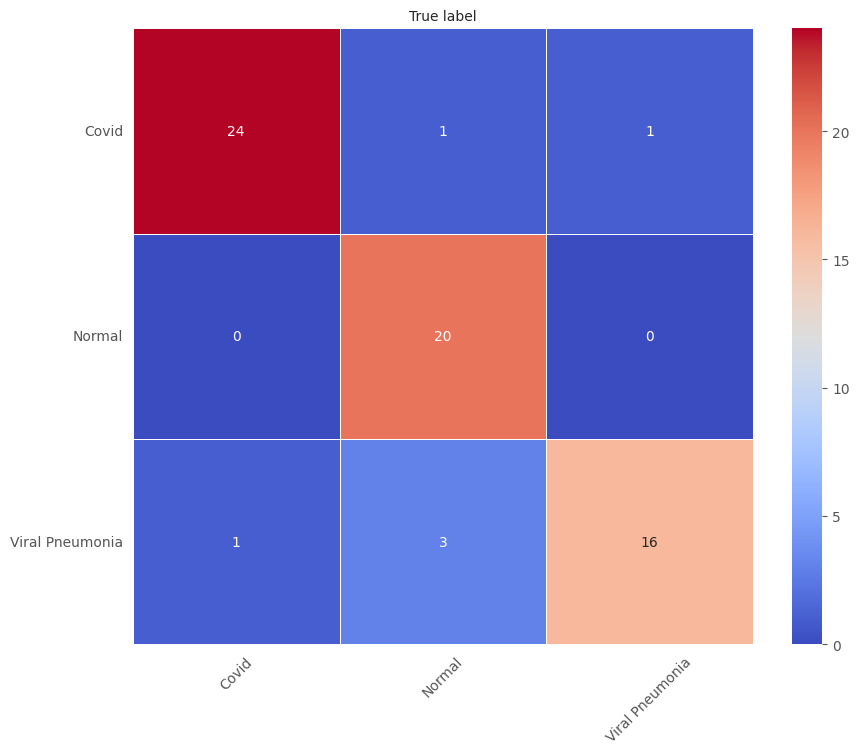

In [43]:
preds= model.predict(test_gen)
y_pred= np.argmax(preds,axis=1)
#class labels
g_dict=test_gen.class_indices
classes=list(g_dict.keys())

#confusion matrix
cm= confusion_matrix(test_gen.classes, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot= True, fmt='d',cmap='coolwarm', xticklabels=classes, yticklabels= classes, linewidths=0.5)
plt.title("Confusion matrix", fontsize=12)
plt.title("Predicted label", fontsize=10)
plt.title("True label", fontsize=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show

In [47]:
model.save("model_Efficent.keras")

* VGG16


In [50]:
img_shape = (img_size[0], img_size[1] , 3)
Num_class= len(classes)
base_model=tf.keras.applications.VGG16(include_top=False,weights=None,input_shape=img_shape,pooling='max')
base_model.load_weights('/kaggle/input/datasets/omarmahmouud/error-downloading/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5')

#Freeze convolutional layers
for layer in base_model.layers:
    layer.trainable = False
    
model_VGG16 = Sequential([
    base_model,
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(Num_class, activation='softmax')
])

model_VGG16.compile(
    optimizer=Adamax(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_VGG16.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,835 (56.64 MB)

 Trainable params: 133,123 (520.01 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [53]:
history_VGG16=model.fit(x=train_gen,epochs=15,verbose=1,validation_data=valid_gen,validation_steps=None,shuffle=False)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 326s 20s/step - accuracy: 0.9887 - loss: 0.0282 - val_accuracy: 0.8788 - val_loss: 0.2385
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 314s 20s/step - accuracy: 0.9951 - loss: 0.0165 - val_accuracy: 0.9091 - val_loss: 0.1945
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 307s 19s/step - accuracy: 0.9986 - loss: 0.0099 - val_accuracy: 0.9091 - val_loss: 0.1935
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 346s 22s/step - accuracy: 0.9809 - loss: 0.0423 - val_accuracy: 0.9394 - val_loss: 0.1010
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 324s 20s/step - accuracy: 0.9987 - loss: 0.0031 - val_accuracy: 0.9394 - val_loss: 0.1090
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 291s 18s/step - accuracy: 0.9968 - loss: 0.0087 - val_accuracy: 0.9394 - val_loss: 0.2392
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 315s 20s/step - accuracy: 0.9910 - loss: 0.0427 - val_accuracy: 0.9091 - val_loss: 0.2101
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 341s 21s/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 0.

Model_VGG16 Evaluation


In [55]:
train_VGG16_acc=history_VGG16.history['accuracy']
train_VGG16_loss=history_VGG16.history['loss']
val_VGG16_acc=history_VGG16.history['val_accuracy']
val_VGG16_loss=history_VGG16.history['val_loss']
index_VGG16_loss=np.argmin(val_VGG16_loss)
val_VGG16_lowest=val_VGG16_loss[index_VGG16_loss]
index_VGG16_acc=np.argmin(val_VGG16_acc)
val_VGG16_highest=val_VGG16_acc[index_VGG16_acc]
Epochs_VGG16=[i+1 for i in range(len(train_VGG16_acc))]
loss_label_VGG16=f'best epochs={str(index_VGG16_loss +1)}'
acc_label_VGG16=f'best epochs={str(index_VGG16_acc +1)}'

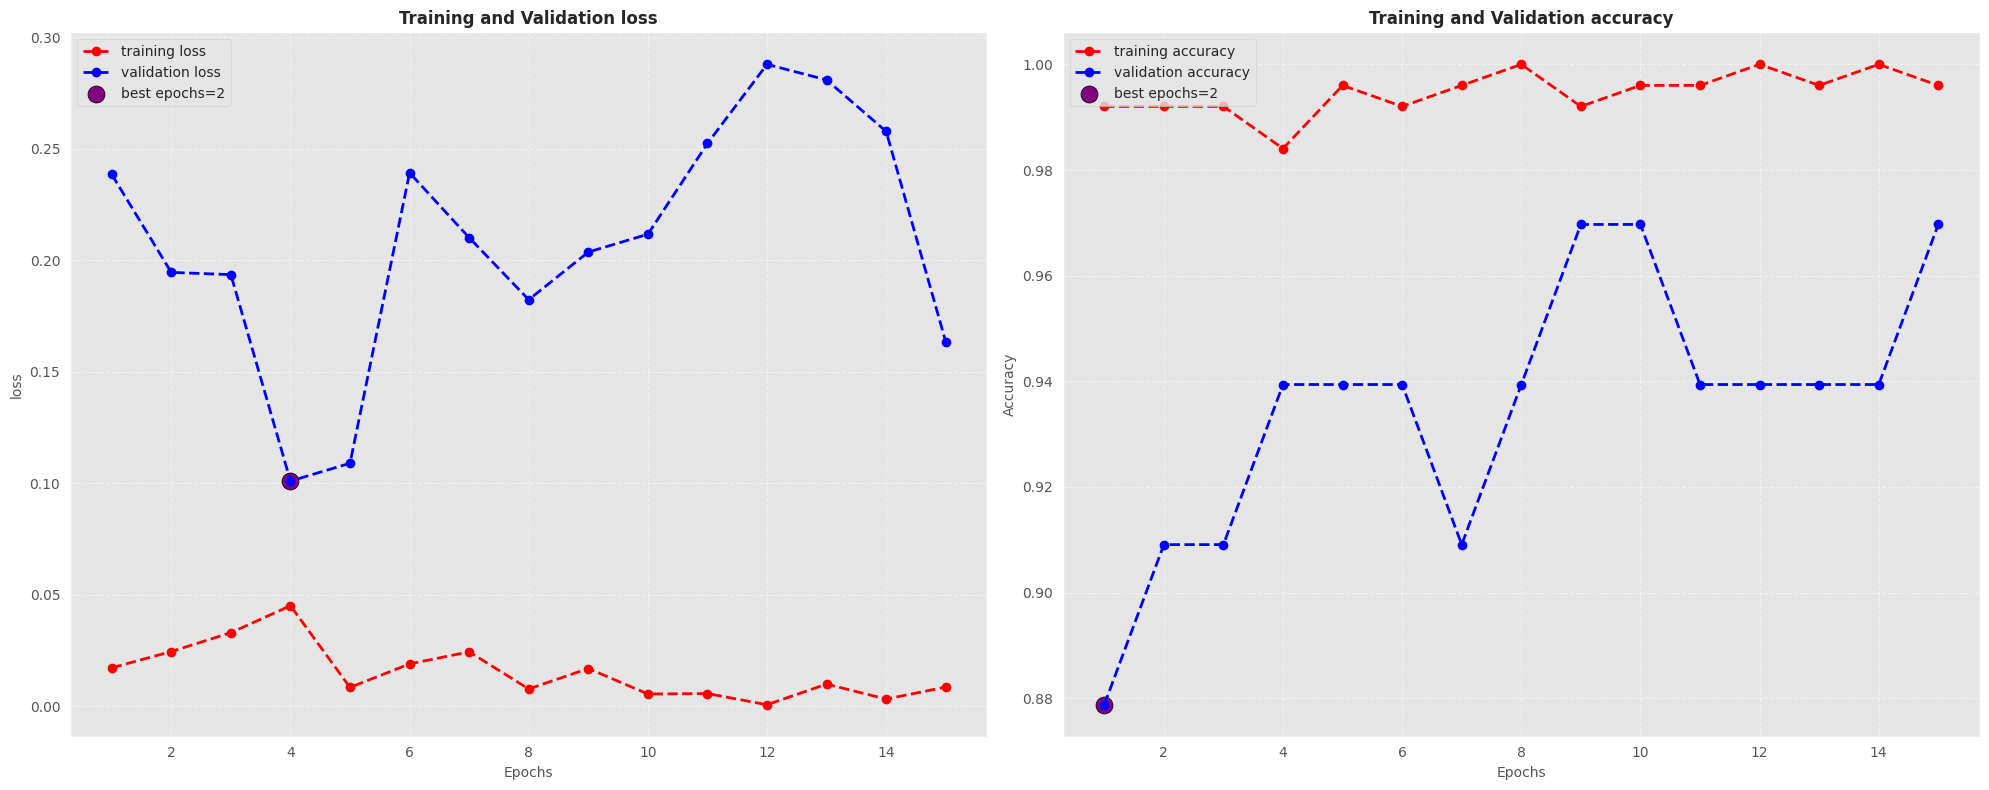

In [56]:
plt.figure(figsize=(20,8))
plt.style.use("ggplot")

#accuracy plot
plt.subplot(1,2,2)
plt.plot(Epochs_VGG16,train_VGG16_acc,'r--',linewidth=2,marker='o',label='training accuracy')
plt.plot(Epochs_VGG16,val_VGG16_acc,'b--',linewidth=2,marker='o',label='validation accuracy')
plt.scatter(index_VGG16_acc +1 ,val_VGG16_highest , s=150 , c='purple', edgecolors='black',label=acc_label)
plt.title("Training and Validation accuracy",fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=10)
plt.ylabel('Accuracy',fontsize=10)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)

#loss plot
plt.subplot(1,2,1)
plt.plot(Epochs_VGG16,train_VGG16_loss,'r--',linewidth=2,marker='o',label='training loss')
plt.plot(Epochs_VGG16,val_VGG16_loss,'b--',linewidth=2,marker='o',label='validation loss')
plt.scatter(index_VGG16_loss +1 ,val_VGG16_lowest , s=150 , c='purple', edgecolors='black',label=acc_label)
plt.title("Training and Validation loss",fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=10)
plt.ylabel('loss',fontsize=10)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)

plt.tight_layout()
plt.show()

In [57]:
train_VGG16_score=model.evaluate(train_gen, steps=16, verbose=1)
val_VGG16_score=model.evaluate(valid_gen, steps=16, verbose=1)
test_VGG16_score=model.evaluate(test_gen, steps=16, verbose=1)
print("train loss",train_VGG16_score[0])
print("train accuracy",train_VGG16_score[1])
print('-'* 20)
print("val loss",val_VGG16_score[0])
print("val accuracy",val_VGG16_score[1])
print('-'* 20)
print("test loss",test_VGG16_score[0])
print("test accuracy",test_VGG16_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 1.0000 - loss: 7.2785e-04
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.9676 - loss: 0.1739
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 802ms/step - accuracy: 0.9844 - loss: 0.0962
train loss 0.0010229996405541897
train accuracy 1.0
--------------------
val loss 0.1634380966424942
val accuracy 0.9696969985961914
--------------------
test loss 0.09180831164121628
test accuracy 0.9848484992980957


Confusion_VGG16 matrix

5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step


<function matplotlib.pyplot.show(close=None, block=None)>

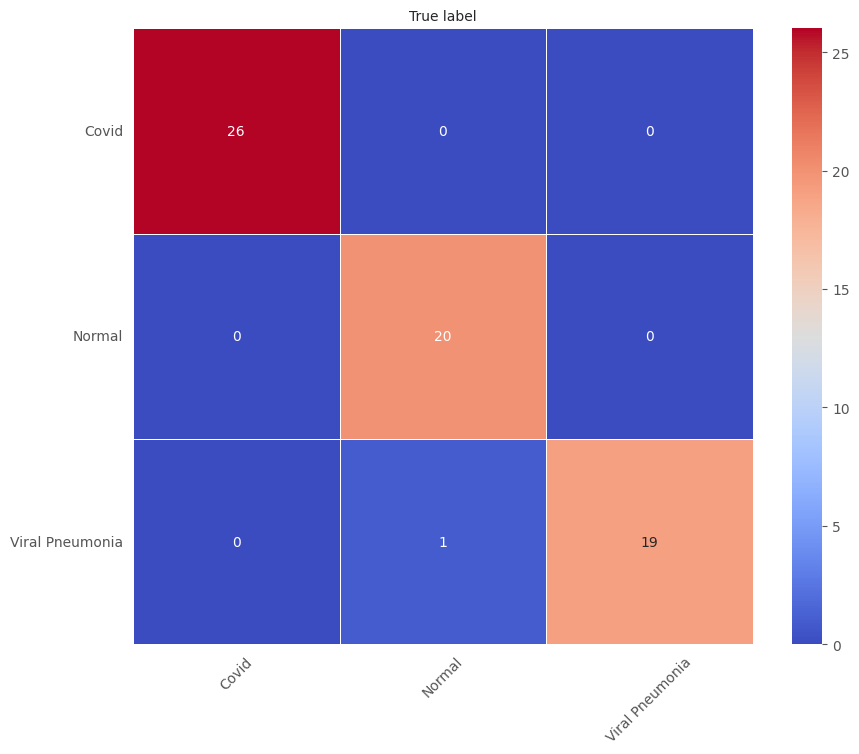

In [58]:
preds_VGG16= model.predict(test_gen)
y_pred_VGG16= np.argmax(preds_VGG16,axis=1)
#class labels
g_VGG16_dict=test_gen.class_indices
classes=list(g_VGG16_dict.keys())

#confusion matrix
cm_VGG16= confusion_matrix(test_gen.classes, y_pred_VGG16)
plt.figure(figsize=(10,8))
sns.heatmap(cm_VGG16,annot= True, fmt='d',cmap='coolwarm', xticklabels=classes, yticklabels= classes, linewidths=0.5)
plt.title("Confusion matrix", fontsize=12)
plt.title("Predicted label", fontsize=10)
plt.title("True label", fontsize=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show

In [59]:
model_VGG16.save('model_VGG16.keras')